In [1]:
import pickle as pkl
import random
import numpy as np
import os

In [2]:
import umap
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns

/home/jienihu/miniconda3/envs/slformer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n200_notransform.pkl", 'rb') as f: 
#     gene2sent_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]

In [4]:
id2gene_map = {i:g for g,i in gene2id_map.items()}
id2cancer_map = {i:cancer for i,cancer in enumerate(cancer_list)}
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [5]:
res_dir = "./experiment/inference/all_SL"

### UMAP

In [6]:
def construct_embdf(embedding, cancer_label, gene_label):

    cancer_col = np.array(cancer_label)
    gene_col = np.array(gene_label)
    data = np.concatenate((embedding, cancer_col.reshape(-1,1), gene_col.reshape(-1,1)),
                          axis=1)
    df = pd.DataFrame(data)
    df.columns = ['pc1', 'pc2', 'cancer', 'gene']

    return df

In [7]:
def plot_single_cancer(plot_df, cancer, title):

    plt.figure(dpi=600)
    cmap = cm.tab20(range(8))

    plt.scatter(plot_df["pc1"], plot_df["pc2"], color="#E41A1C", s=0.1, marker='o')
        
    plt.legend(prop={"size": 4},  loc='upper right')
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')
    plt.title(f"{title}_{cancer}")
    
    plt.savefig(os.path.join("./data/img/", f"{title}_{cancer}_singlecancer.png"), bbox_inches='tight', dpi=600)

In [8]:
def plot_by_cancer(plot_df, title):

    plt.figure(dpi=600)
    cmap = cm.tab20(range(8))

    for i, cancer in enumerate(['BRCA', 'CESC', 'KIRC', 'LUAD', 'OV', 'COAD', 'LAML', 'SKCM']):

        subset_plot = plot_df[plot_df["cancer"]==cancer]
        plt.scatter(subset_plot["pc1"], subset_plot["pc2"], color=cmap[i], s=0.1, marker='o',
                    label=cancer)
        
    plt.legend(prop={"size": 4},  loc='upper right')
    plt.xlabel('UMAP-1')
    plt.ylabel('UMAP-2')
    plt.title(title)
    
    plt.savefig(os.path.join("./data/img/", f"{title}_bycancer.png"), bbox_inches='tight', dpi=600)

In [9]:
def plot_by_gene(plot_df, title):

    plt.figure(dpi=600)
    cmap = cm.tab20(range(19))

    random.seed(1)
    gene_total = list(set(plot_df["gene"]))
    random.shuffle(gene_total)
    # gene_sample = gene_total[:10]
    gene_sample = ['PARP1','FGFR2','TOP1','GATA3','HSP90AA1','CDH1','MET','CHEK1','HDAC1','CDK6']
    # gene_background = gene_total[10:]
    gene_background = [g for g in gene_total if g not in gene_sample]

    background_bool = [True if g in gene_background else False for g in list(plot_df["gene"])]
    subset_plot_background = plot_df[background_bool]
    plt.scatter(subset_plot_background["pc1"], subset_plot_background["pc2"], color='lightgray', s=0.05, marker='o', alpha=0.5,
                label="other")

    for i, g in enumerate(gene_sample):
        subset_plot = plot_df[plot_df["gene"]==g]
        plt.scatter(subset_plot["pc1"], subset_plot["pc2"], color=cmap[i], s=1, marker='o',
                    label=g)


    plt.legend(prop={"size": 4},  loc='upper right')
    plt.title(title)
    plt.savefig(os.path.join("./data/img/", f"{title}_bygene.png"), bbox_inches='tight', dpi=600)

In [12]:

def plot_emb(name, cancer):
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
    # with open(os.path.join(res_dir, f"{name}_crossemb.pkl"), 'rb') as f: 
        emb = pkl.load(f)
    ## (data size, 20, 512)
    
    if emb[0][0].ndim == 2:
        emb_gene1 = [emb[i][0] for i in range(5)]
        emb_gene2 = [emb[i][1] for i in range(5)]
    else:
        emb_gene1 = [emb[i][0][:,0,:] for i in range(5)]
        emb_gene2 = [emb[i][1][:,0,:] for i in range(5)]
    emb1_cat = np.concatenate(emb_gene1, axis=0)
    emb2_cat = np.concatenate(emb_gene2, axis=0)
    emb_total = np.concatenate([emb1_cat, emb2_cat], axis=0)

    df_all = [pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv")) for cv in range(1,6)]
    context_cat = pd.concat([df['cancer'] for df in df_all]).tolist()*2
    gene1_cat = pd.concat([df['primary_gene'] for df in df_all]).tolist()
    gene2_cat = pd.concat([df['partner_gene'] for df in df_all]).tolist()
    gene_total = gene1_cat+gene2_cat

    gene_norep = list(set(gene_total))
    gene_norep.sort()
    unique_idx = [i for i,g in enumerate(gene_total) if g in gene_norep]
    gene_unique = [gene_total[i] for i in unique_idx]
    emb_unique = emb_total[unique_idx, :]
    context_unique = [context_cat[i] for i in unique_idx]

    if cancer != 'all':
        ## data in a specific cancer
        cancer_idx = [i for i,c in enumerate(context_unique) if c==cancer]
        emb_cancer = emb_unique[cancer_idx,:]
        gene_cancer = gene_norep[cancer_idx,:]

    # name = name+"_cross"

    # UMAP
    reducer = umap.UMAP(n_neighbors=30)
    # reducer = umap.UMAP()
    if cancer == 'all':
        embedding = reducer.fit_transform(emb_unique)
        plot_df = construct_embdf(embedding, context_unique, gene_unique)
        plot_df.to_csv(os.path.join("./data/img/", f"{name}_{cancer}.csv"))
        plot_by_cancer(plot_df, name)
        plot_by_gene(plot_df, name)
    else:
        embedding = reducer.fit_transform(emb_cancer)
        plot_df = construct_embdf(embedding, [cancer]*len(gene_cancer), gene_cancer)
        plot_df.to_csv(os.path.join("./data/img/", f"{name}_{cancer}.csv"))
        plot_single_cancer(plot_df, cancer, name)

    
    


In [ ]:
for name in ["mix_slformer_kg", "mix_slformer_nokg"]:
    plot_emb(name, cancer='all')

### Similarity

In [6]:
def get_emb(name, cancer):
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
    # with open(os.path.join(res_dir, f"{name}_crossemb.pkl"), 'rb') as f: 
        emb = pkl.load(f)
    ## (data size, 20, 512)
    
    if emb[0][0].ndim == 2:
        emb_gene1 = [emb[i][0] for i in range(5)]
        emb_gene2 = [emb[i][1] for i in range(5)]
    else:
        emb_gene1 = [emb[i][0][:,0,:] for i in range(5)]
        emb_gene2 = [emb[i][1][:,0,:] for i in range(5)]
    emb1_cat = np.concatenate(emb_gene1, axis=0)
    emb2_cat = np.concatenate(emb_gene2, axis=0)
    emb_total = np.concatenate([emb1_cat, emb2_cat], axis=0)

    df_all = [pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv")) for cv in range(1,6)]
    context_cat = pd.concat([df['cancer'] for df in df_all]).tolist()*2
    gene1_cat = pd.concat([df['primary_gene'] for df in df_all]).tolist()
    gene2_cat = pd.concat([df['partner_gene'] for df in df_all]).tolist()
    gene_total = gene1_cat+gene2_cat
    gene_total_df = pd.DataFrame({'gene':gene_total,'context':context_cat})
    gene_total_df = gene_total_df.drop_duplicates(keep='first')
    unique_idx = gene_total_df.index

    # gene_norep = list(set(gene_total))
    # gene_norep.sort()
    # unique_idx = [i for i,g in enumerate(gene_total) if g not in gene_norep[:i]]
    gene_unique = [gene_total[i] for i in unique_idx]
    emb_unique = emb_total[unique_idx, :]
    context_unique = [context_cat[i] for i in unique_idx]

    return gene_unique, emb_unique, context_unique
    

In [7]:
def cos_sim(A,B):
    dot_product = np.dot(A, B)

    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    cosine_similarity = dot_product / (norm_A * norm_B)

    return cosine_similarity


def calc_sim(gene, emb, context, n_sample=50):
    gene_context_df = pd.DataFrame({"gene": gene, "context": context})
    gene_selected = gene_context_df['gene'].value_counts().index[:n_sample]
    np.random.seed(1)
    cos_sim_all = []
    
    for g in gene_selected:
        gene_df = gene_context_df[gene_context_df['gene']==g]
        idx = gene_df.index
        for i in range(len(gene_df)):
            for j in range(i+1, len(gene_df)):
                cos_sim_all.append({
                    'gene': g,
                    'cancer1': gene_df['context'][idx[i]],
                    'cancer2': gene_df['context'][idx[j]],
                    'cos_sim': cos_sim(emb[idx[i]], emb[idx[j]])
                })
                # cos_sim_all.append(cos_sim(emb[idx[i]], emb[idx[j]]))

    return gene_selected, pd.DataFrame(cos_sim_all)

def calc_sim_geneformer(gene_selected):
    with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
        geneformer_emb = pkl.load(f)
    cos_sim_all = []

    try:
        for g in gene_selected:
            g_idx = gene2id_map[g]
            for i in range(8):
                for j in range(i+1,8):
                    cos_sim_all.append({
                        'gene': g,
                        'cancer1': id2cancer_map[i],
                        'cancer2': id2cancer_map[j],
                        'cos_sim': cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx])
                    })
                    # cos_sim_all.append(cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx]))
    except:
        print(f"not found {g_idx}")

    return pd.DataFrame(cos_sim_all)


In [8]:
# for name in ["mix_slformer_kg", "mix_slformer_nokg"]:
gene, emb, context = get_emb("mix_slformer_kg", cancer='all')
gene_selected, cos_sim_all_kg = calc_sim(gene, emb, context)

In [9]:
gene, emb, context = get_emb("mix_slformer_nokg", cancer='all')
gene_selected, cos_sim_all_nokg = calc_sim(gene, emb, context)

In [9]:
cos_sim_geneformer = calc_sim_geneformer(gene_selected)

not found 6623


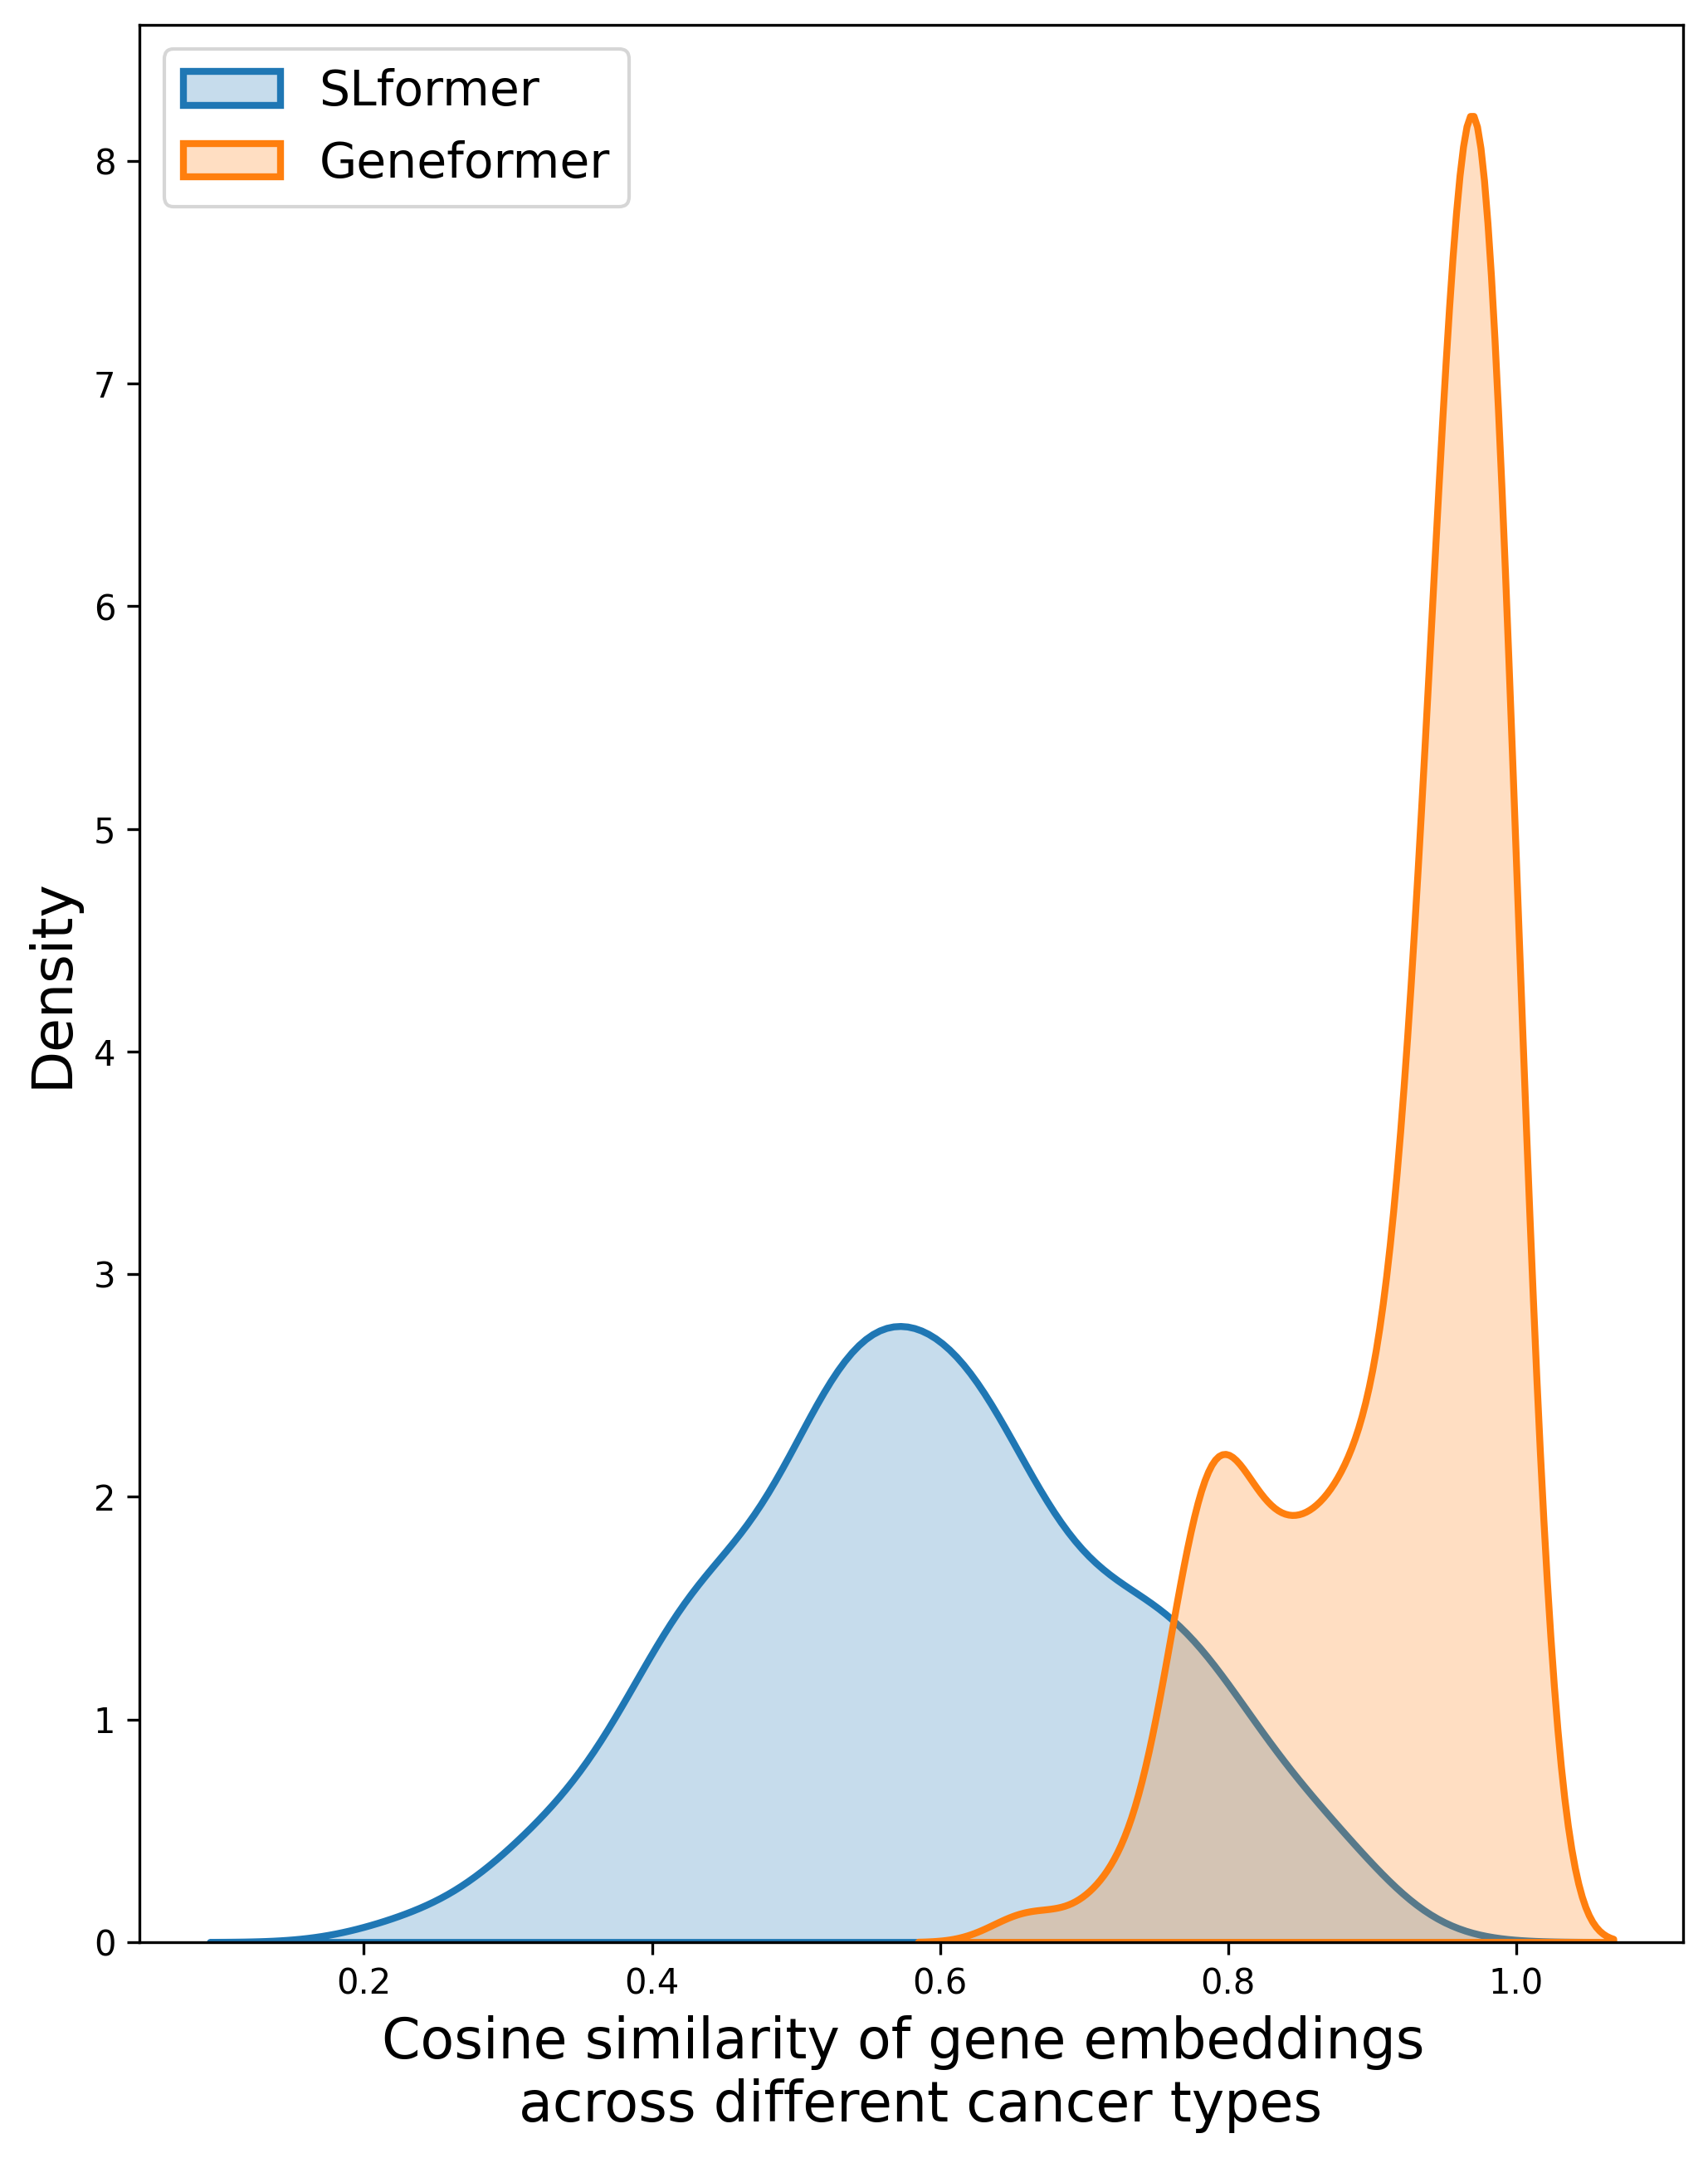

In [10]:

bins = 30
plt.figure(figsize=(8,10), dpi=300)

sns.kdeplot(cos_sim_all_kg['cos_sim'], fill=True, linewidth=2, label='SLformer') ## color=''
# sns.kdeplot(cos_sim_all_nokg['cos_sim'], label='SLformer after training (noKG)')
sns.kdeplot(cos_sim_geneformer['cos_sim'], fill=True, linewidth=2, label='Geneformer')

# sns.histplot(cos_sim_all_kg['cos_sim'], kde=True, element="poly", linewidth=1.5, fill=False, bins=bins, label='SLformer after training')
# sns.histplot(cos_sim_all_nokg['cos_sim'], kde=True, element="poly", linewidth=1.5, fill=False, bins=bins, label='SLformer after training (noKG)')
# sns.histplot(cos_sim_geneformer['cos_sim'], kde=True, element="poly", linewidth=1.5, fill=False, bins=bins, label='Geneformer emb')

plt.legend(loc='upper left', fontsize=14)
plt.xlabel('Cosine similarity of gene embeddings \n across different cancer types', fontsize=16)
plt.ylabel('Density', fontsize=16)

plt.show()

In [21]:
cos_sim_all_nokg_sorted = cos_sim_all_nokg.sort_values(by='cos_sim', ascending=False)
cos_sim_all_nokg_sorted.to_csv('experiment/inference/all_SL/cos_sim_nokg_sorted.csv', index=False)

In [22]:
cos_sim_all_kg_sorted = cos_sim_all_kg.sort_values(by='cos_sim', ascending=False)
cos_sim_all_kg_sorted.to_csv('experiment/inference/all_SL/cos_sim_kg_sorted.csv', index=False)

### functional similarity

In [8]:
import gseapy as gp

In [18]:
msigdb_gene_sets = gp.read_gmt('data/gene_function/c2.all.v2024.1.Hs.symbols.gmt')

# The result is a dictionary where keys are gene set names and values are lists of genes
# Example: msigdb_gene_sets["HALLMARK_TNFA_SIGNALING_VIA_NFKB"]

In [19]:
all_pathways = list(msigdb_gene_sets.keys())
rdn_idx = np.random.randint(len(all_pathways), size=50)


dict_keys(['ABBUD_LIF_SIGNALING_1_DN', 'ABBUD_LIF_SIGNALING_1_UP', 'ABBUD_LIF_SIGNALING_2_DN', 'ABBUD_LIF_SIGNALING_2_UP', 'ABDELMOHSEN_ELAVL4_TARGETS', 'ABDULRAHMAN_KIDNEY_CANCER_VHL_DN', 'ABE_INNER_EAR', 'ABE_VEGFA_TARGETS', 'ABE_VEGFA_TARGETS_2HR', 'ABE_VEGFA_TARGETS_30MIN', 'ABRAHAM_ALPC_VS_MULTIPLE_MYELOMA_DN', 'ABRAHAM_ALPC_VS_MULTIPLE_MYELOMA_UP', 'ABRAMSON_INTERACT_WITH_AIRE', 'ACEVEDO_LIVER_CANCER_DN', 'ACEVEDO_LIVER_CANCER_UP', 'ACEVEDO_LIVER_CANCER_WITH_H3K27ME3_DN', 'ACEVEDO_LIVER_CANCER_WITH_H3K27ME3_UP', 'ACEVEDO_LIVER_CANCER_WITH_H3K9ME3_DN', 'ACEVEDO_LIVER_CANCER_WITH_H3K9ME3_UP', 'ACEVEDO_LIVER_TUMOR_VS_NORMAL_ADJACENT_TISSUE_DN', 'ACEVEDO_LIVER_TUMOR_VS_NORMAL_ADJACENT_TISSUE_UP', 'ACEVEDO_METHYLATED_IN_LIVER_CANCER_DN', 'ACEVEDO_NORMAL_TISSUE_ADJACENT_TO_LIVER_TUMOR_DN', 'ACEVEDO_NORMAL_TISSUE_ADJACENT_TO_LIVER_TUMOR_UP', 'ACOSTA_PROLIFERATION_INDEPENDENT_MYC_TARGETS_DN', 'ACOSTA_PROLIFERATION_INDEPENDENT_MYC_TARGETS_UP', 'ADDYA_ERYTHROID_DIFFERENTIATION_BY_HEMIN', '

In [11]:
def calc_sim_genes(gene, emb, context, n_sample=50):

    gene_context_df = pd.DataFrame({"gene": gene, "context": context})
    context_all = list(set(gene_context_df['context']))
    context_all.sort()
    np.random.seed(1)
    cos_sim_all = []

    for cancer in context_all:
        df_cancer = gene_context_df[gene_context_df['context']==cancer]
        df_pairs = [df_cancer.sample(2, random_state=i, replace=False) for i in range(n_sample)]

        for pairs in df_pairs:
            idx = pairs.index
            cos_sim_all.append({
                'gene1': pairs['gene'].iloc[0],
                'gene2': pairs['gene'].iloc[1],
                'context': cancer,
                'cos_sim': cos_sim(emb[idx[0]], emb[idx[1]])
            })
        
    return pd.DataFrame(cos_sim_all)


def calc_sim_genes_geneformer(df):
    with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
        geneformer_emb = pkl.load(f)
    cos_sim_all = []

    for i, row in df.iterrows():
        try:
            cancer_idx = cancer2id_map[row['context']]
            g1_idx = gene2id_map[row['gene1']]
            g2_idx = gene2id_map[row['gene2']]
            cos_sim_all.append({
                'gene1': row['gene1'],
                'gene2': row['gene2'],
                'context': row['context'],
                'cos_sim': cos_sim(geneformer_emb[cancer_idx][g1_idx], geneformer_emb[cancer_idx][g2_idx])
            })
            # cos_sim_all.append(cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx]))
        except:
            print(f"not found genes")

    return pd.DataFrame(cos_sim_all)

In [27]:
# for name in ["mix_slformer_kg", "mix_slformer_nokg"]:
gene, emb, context = get_emb("mix_slformer_kg", cancer='all')

In [28]:
cos_sim_all_kg = calc_sim_genes(gene, emb, context, n_sample=500)

In [15]:
cos_sim_all_kg.to_csv("experiment/inference/all_SL/func_cos_sim_kg_500.csv", index=False)

In [70]:
def plot_func_sim(df):
    data_pos = df[df['FS'] > 0]
    data_neg = df[df['FS'] <= 0]
    
    plt.figure(figsize=(10, 6))
    bins = 30

    sns.histplot(data_pos['cos_sim'], kde=False, element="step", linewidth=1.5, fill=False, bins=bins, label='genes with higher function similarity')
    sns.histplot(data_neg['cos_sim'], kde=False, element="step", linewidth=1.5, fill=False, bins=bins, label='genes with lower function similarity')

    # plt.hist(data_pos['cos_sim'], bins=bins, alpha=0.5, label='genes with higher function similarity')
    # plt.hist(data_neg['cos_sim'], bins=bins, alpha=0.5, label='genes with lower function similarity')

    plt.legend()
    # plt.title("slformer mix w/o kg")
    plt.title("geneformer")
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')

    plt.show()

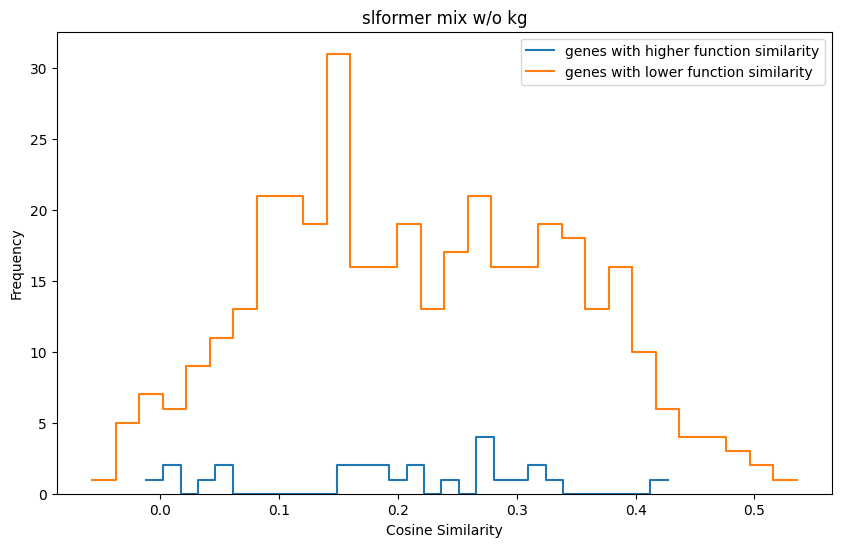

In [39]:
func_sim_kg = pd.read_csv("experiment/inference/all_SL/func_sim_kg.csv")
func_sim_kg['cos_sim'] = cos_sim_all_kg['cos_sim']
plot_func_sim(func_sim_kg)

In [68]:
cos_sim_all_geneformer = calc_sim_genes_geneformer(cos_sim_all_kg)
cos_sim_all_geneformer['FS'] = func_sim_kg['FS']
cos_sim_all_geneformer.head()

,gene1,gene2,cancer,cos_sim,FS
0,CD4,COPB2,BRCA,0.289155,0.546434
1,DGKQ,SERPINH1,BRCA,0.153598,0.489255
2,PPP2R3A,SLC39A4,BRCA,0.235924,0.210190
3,UBA2,DNAJC19,BRCA,0.249307,0.480297
4,STK19,RAI14,BRCA,0.223378,0.342250


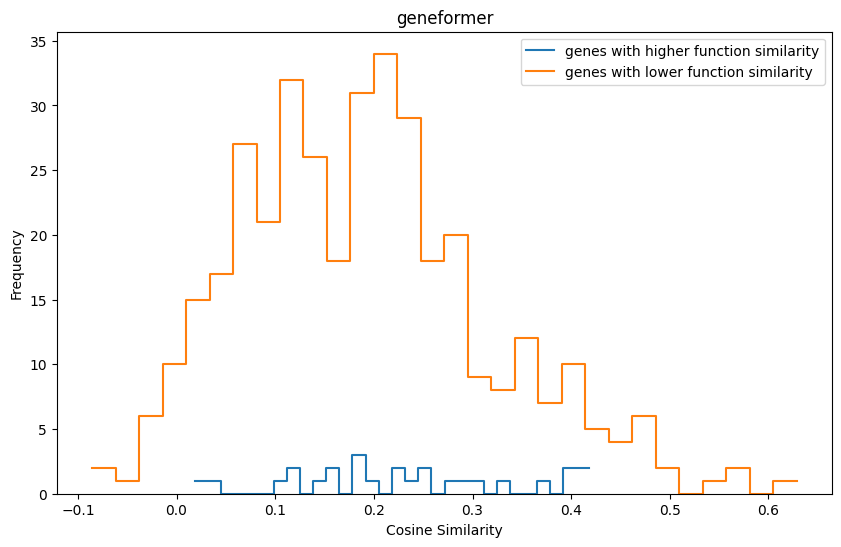

In [71]:
plot_func_sim(cos_sim_all_geneformer)

### shared GO terms

In [12]:
from goatools.obo_parser import GODag
from goatools.associations import read_gaf

go_dag = GODag("data/GO/go-basic.obo")
annotations = read_gaf("data/GO/goa_human.gaf", go_dag=go_dag)

data/GO/go-basic.obo: fmt(1.2) rel(2024-06-17) 45,494 Terms
HMS:0:00:13.982417 707,170 annotations READ: data/GO/goa_human.gaf 
36129 IDs in loaded association branch, BP


In [43]:
with open(os.path.join("data/GO/unprot_ids.txt"), 'w') as fp:
    for a in list(annotations.keys()):
        fp.write("%s\n" % a)

In [13]:
id_mapping = pd.read_csv("data/GO/idmapping_2024_11_09.tsv", sep='\t')
id_mapping = dict(zip(id_mapping['From'], id_mapping['To']))

In [14]:
anno_mapped = {}
for k, v in annotations.items():
    if k in id_mapping:
        anno_mapped[id_mapping[k]] = v

In [15]:
len(anno_mapped.keys())

17575

In [16]:
def find_shared_goterms(gene1, gene2):

    go_terms_gene1 = {go_id for go_id in anno_mapped.get(gene1, [])}
    go_terms_gene2 = {go_id for go_id in anno_mapped.get(gene2, [])}

    shared_go_terms = go_terms_gene1.intersection(go_terms_gene2)

    return len(shared_go_terms)


def pairs_shared_goterms(df):

    ngoterm_all = []

    for i in range(len(df)):
        gene1 = df['gene1'][i]
        gene2 = df['gene2'][i]
        nshared_go_terms = find_shared_goterms(gene1, gene2)
        ngoterm_all.append(nshared_go_terms)

    return ngoterm_all


In [17]:
## ["mix_slformer_kg", "mix_slformer_nokg"]
gene, emb, context = get_emb("mix_slformer_kg", cancer='all')
cos_sim_all_kg = calc_sim_genes(gene, emb, context, n_sample=5000)

In [49]:
gene, emb, context = get_emb("mix_slformer_nokg", cancer='all')
cos_sim_all_nokg = calc_sim_genes(gene, emb, context, n_sample=5000)

In [18]:
cos_sim_all_geneformer = calc_sim_genes_geneformer(cos_sim_all_kg)

In [19]:
nshared_go_terms = pairs_shared_goterms(cos_sim_all_kg)

In [20]:
cos_sim_all_kg['nshared_go_terms'] = nshared_go_terms
# cos_sim_all_nokg['nshared_go_terms'] = nshared_go_terms
cos_sim_all_geneformer['nshared_go_terms'] = nshared_go_terms

cos_sim_all_kg = cos_sim_all_kg.sort_values(by='nshared_go_terms', ascending=False)
# cos_sim_all_nokg = cos_sim_all_nokg.sort_values(by='nshared_go_terms', ascending=False)
cos_sim_all_geneformer = cos_sim_all_geneformer.sort_values(by='nshared_go_terms', ascending=False)

In [21]:
cos_sim_all_kg = cos_sim_all_kg.drop_duplicates(keep='first')
# cos_sim_all_nokg = cos_sim_all_nokg.drop_duplicates(keep='first')
cos_sim_all_geneformer = cos_sim_all_geneformer.drop_duplicates(keep='first')

In [53]:
len([n for n in cos_sim_all_kg['nshared_go_terms'] if n >= 3])

1221

In [22]:
def plot_func_sim_bycancer(df, go_thr=3):

    plt.figure(figsize=(15, 6))
    for i, cancer in enumerate(list(cancer2id_map.keys())):
        if i < 8:
            df_cancer = df[df['context']==cancer]
        
            df_cancer_high = df_cancer[df_cancer['nshared_go_terms']>=go_thr]
            df_cancer_low = df_cancer.iloc[-len(df_cancer_high):,:]

            plt.subplot(2, 4, i+1)
            sns.kdeplot(df_cancer_high['cos_sim'], label='gene pairs with similar functions')
            sns.kdeplot(df_cancer_low['cos_sim'], label='gene pairs with nonsimilar functions')

            # plt.legend()
            plt.title(cancer)
            plt.xlabel('Cosine Similarity')
            plt.ylabel('Density')

    plt.legend()
    plt.tight_layout()
    plt.show()

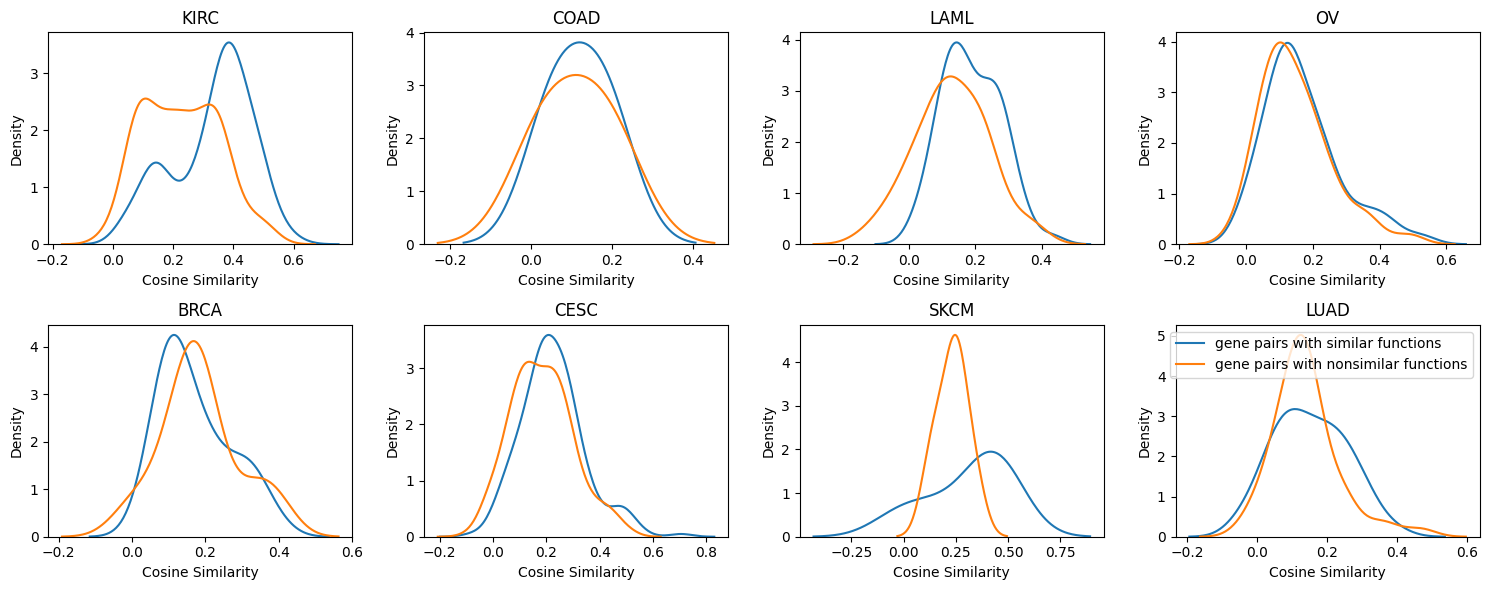

In [101]:
plot_func_sim_bycancer(cos_sim_all_kg, go_thr=4)

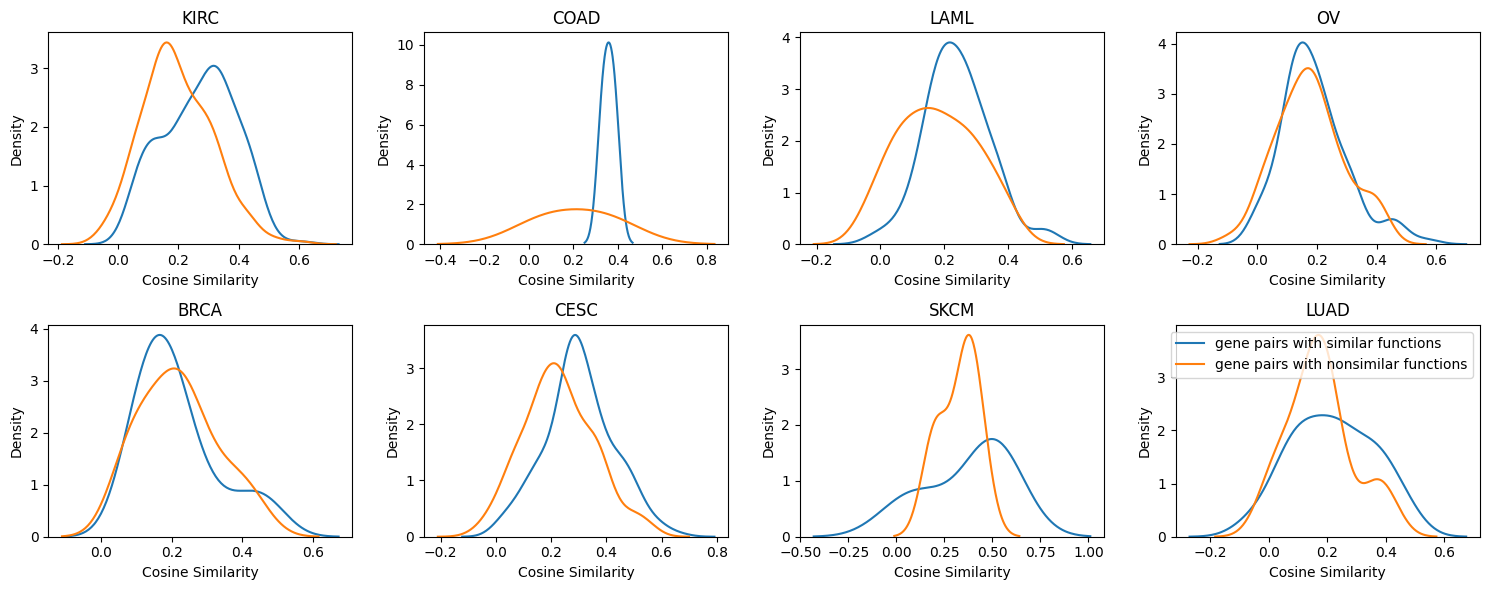

In [103]:
plot_func_sim_bycancer(cos_sim_all_nokg, go_thr=4)

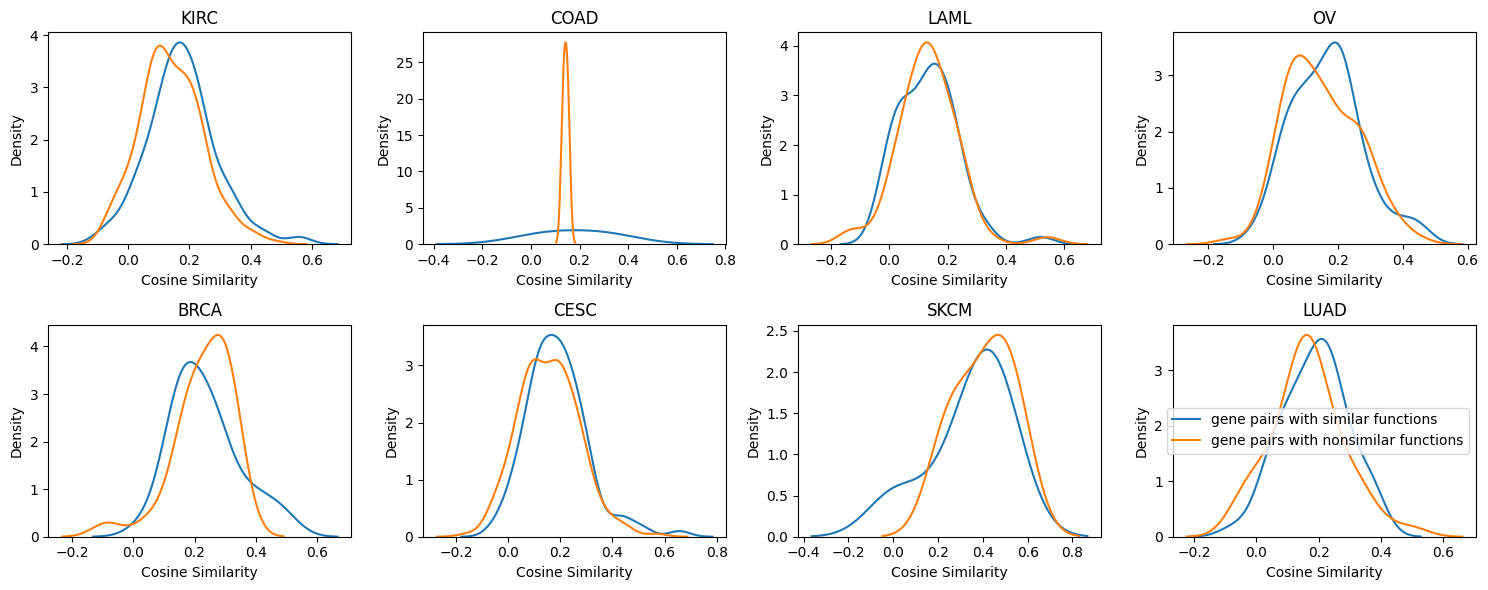

In [104]:
plot_func_sim_bycancer(cos_sim_all_geneformer, go_thr=4)

In [23]:
def plot_func_sim_allcancer(df, title, go_thr=3):

    plt.figure(figsize=(14, 6), dpi=300)
    
    df_high = df[df['nshared_go_terms']>=go_thr]
    df_low = df.iloc[-len(df_high):,:]

    sns.kdeplot(df_high['cos_sim'], fill=True, linewidth=2, label='gene pairs with similar functions', color='#1CE17F')
    sns.kdeplot(df_low['cos_sim'], fill=True, linewidth=2, label='gene pairs with dissimilar functions', color='#FA512F')

    # plt.title(title, fontsize=15)
    plt.xlabel('Cosine Similarity of pairs of gene embeddings in the same cancer', fontsize=18)
    plt.ylabel('Density', fontsize=18)
    plt.legend(fontsize=14)
    plt.show()

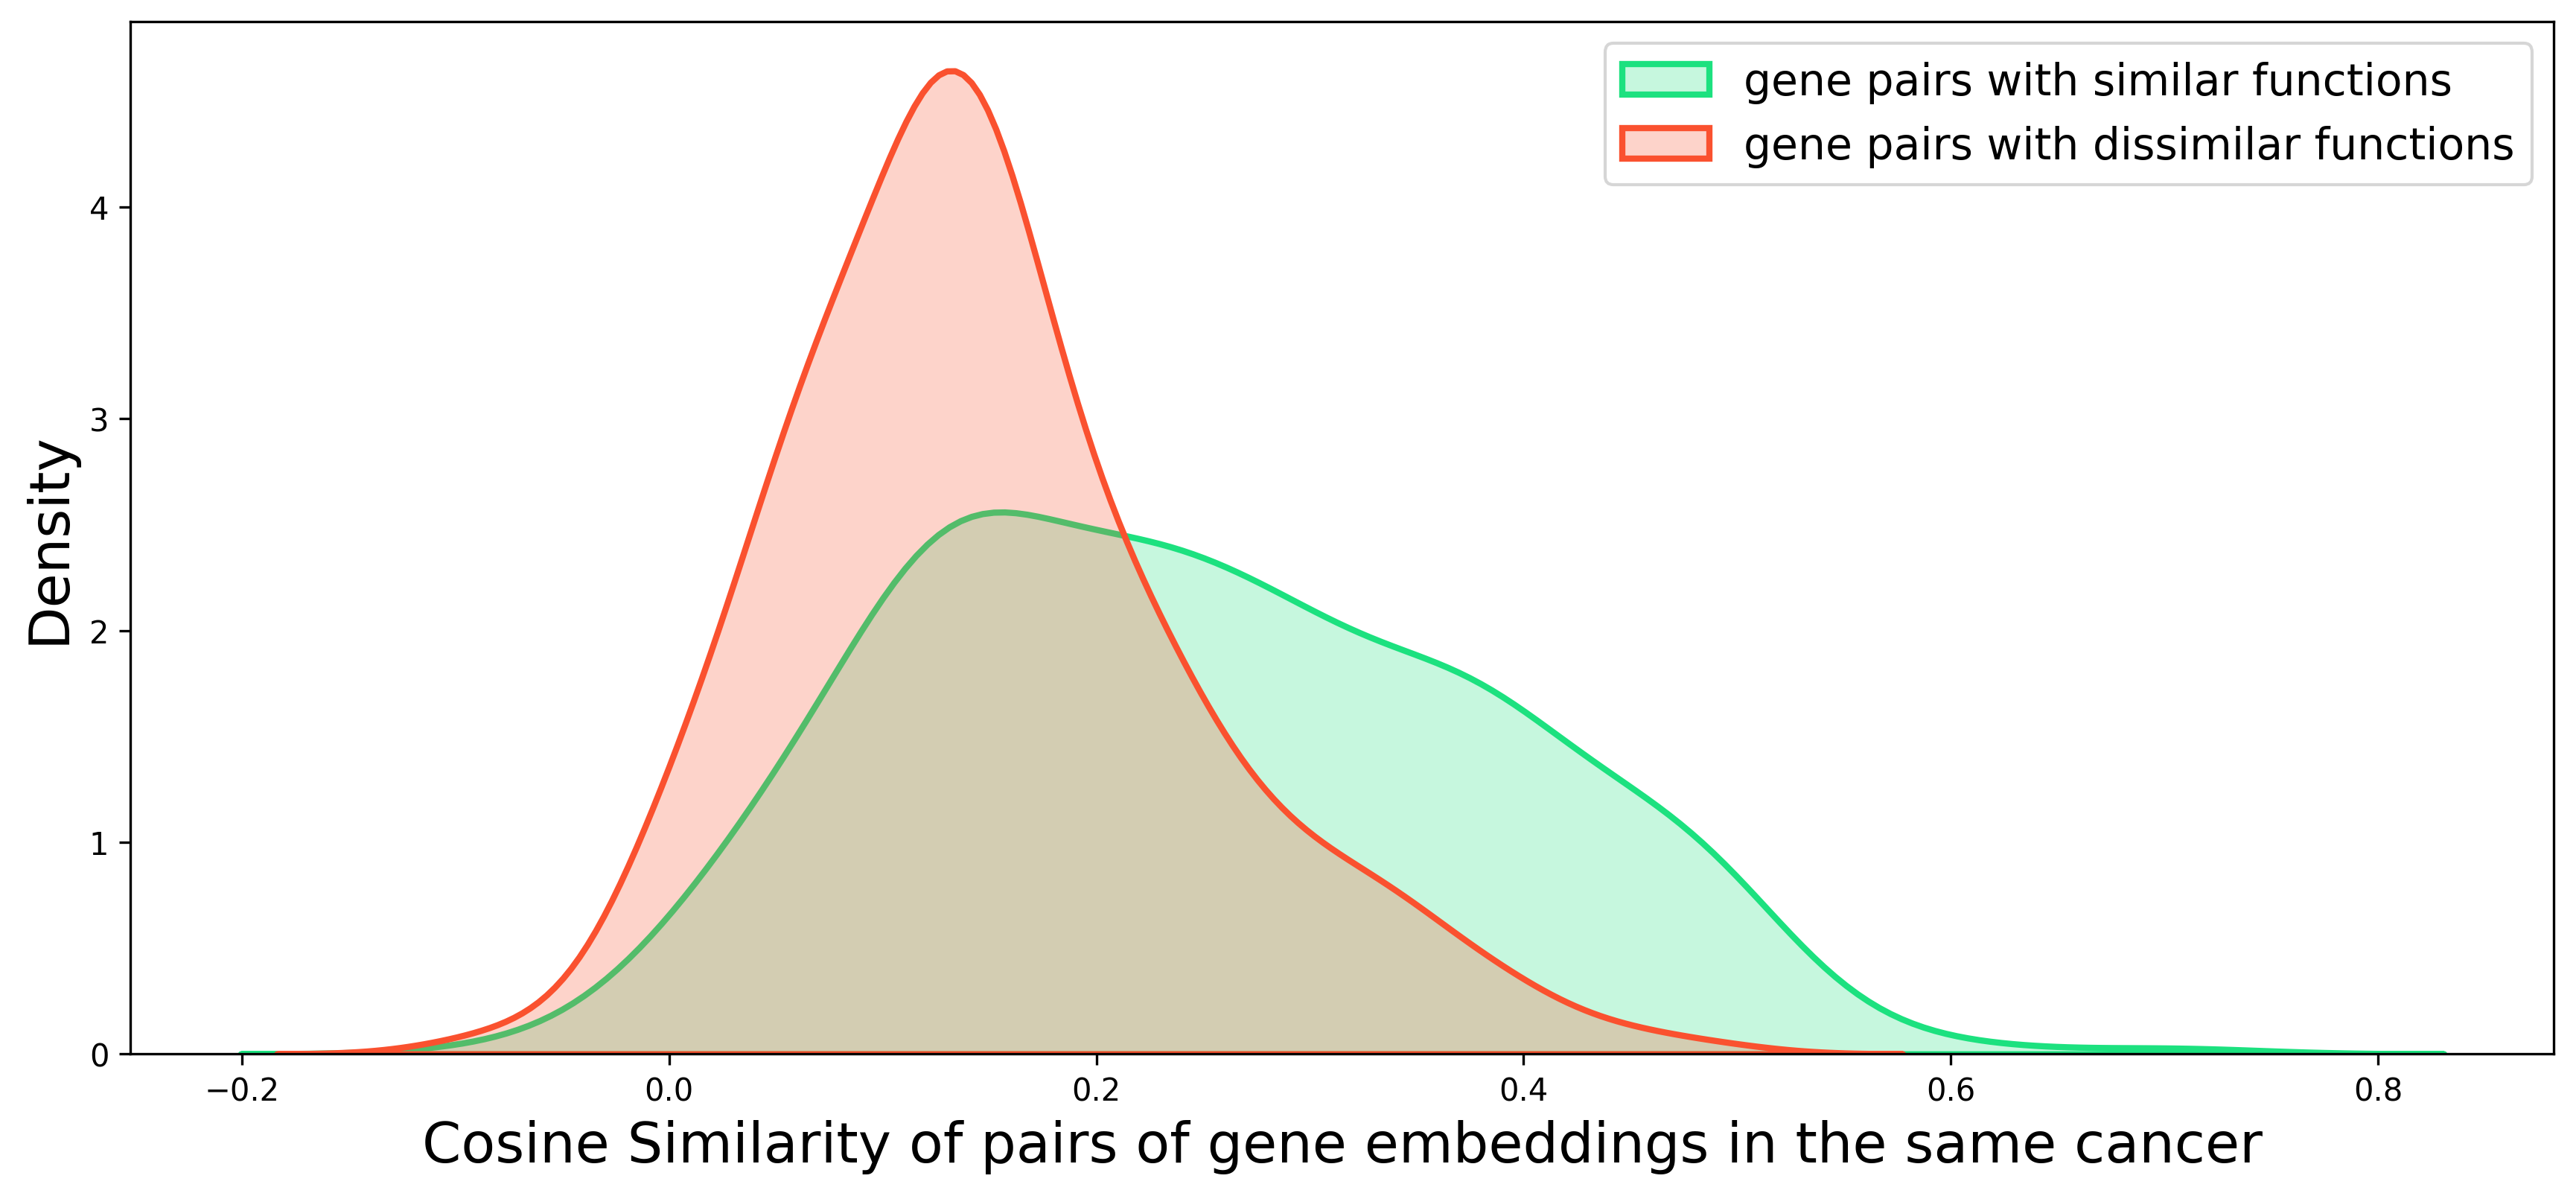

In [55]:
plot_func_sim_allcancer(cos_sim_all_kg, title="Trained SLformer", go_thr=5)

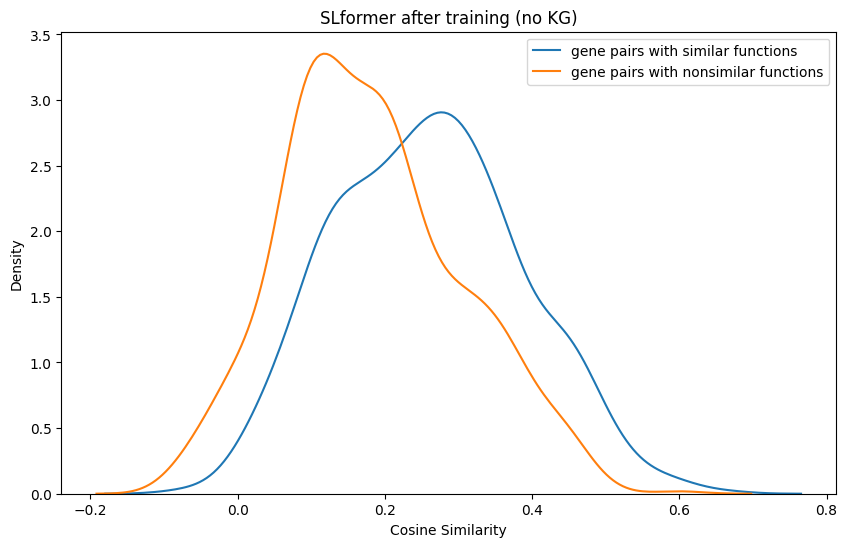

In [33]:
plot_func_sim_allcancer(cos_sim_all_nokg, title="SLformer after training (no KG)", go_thr=4)

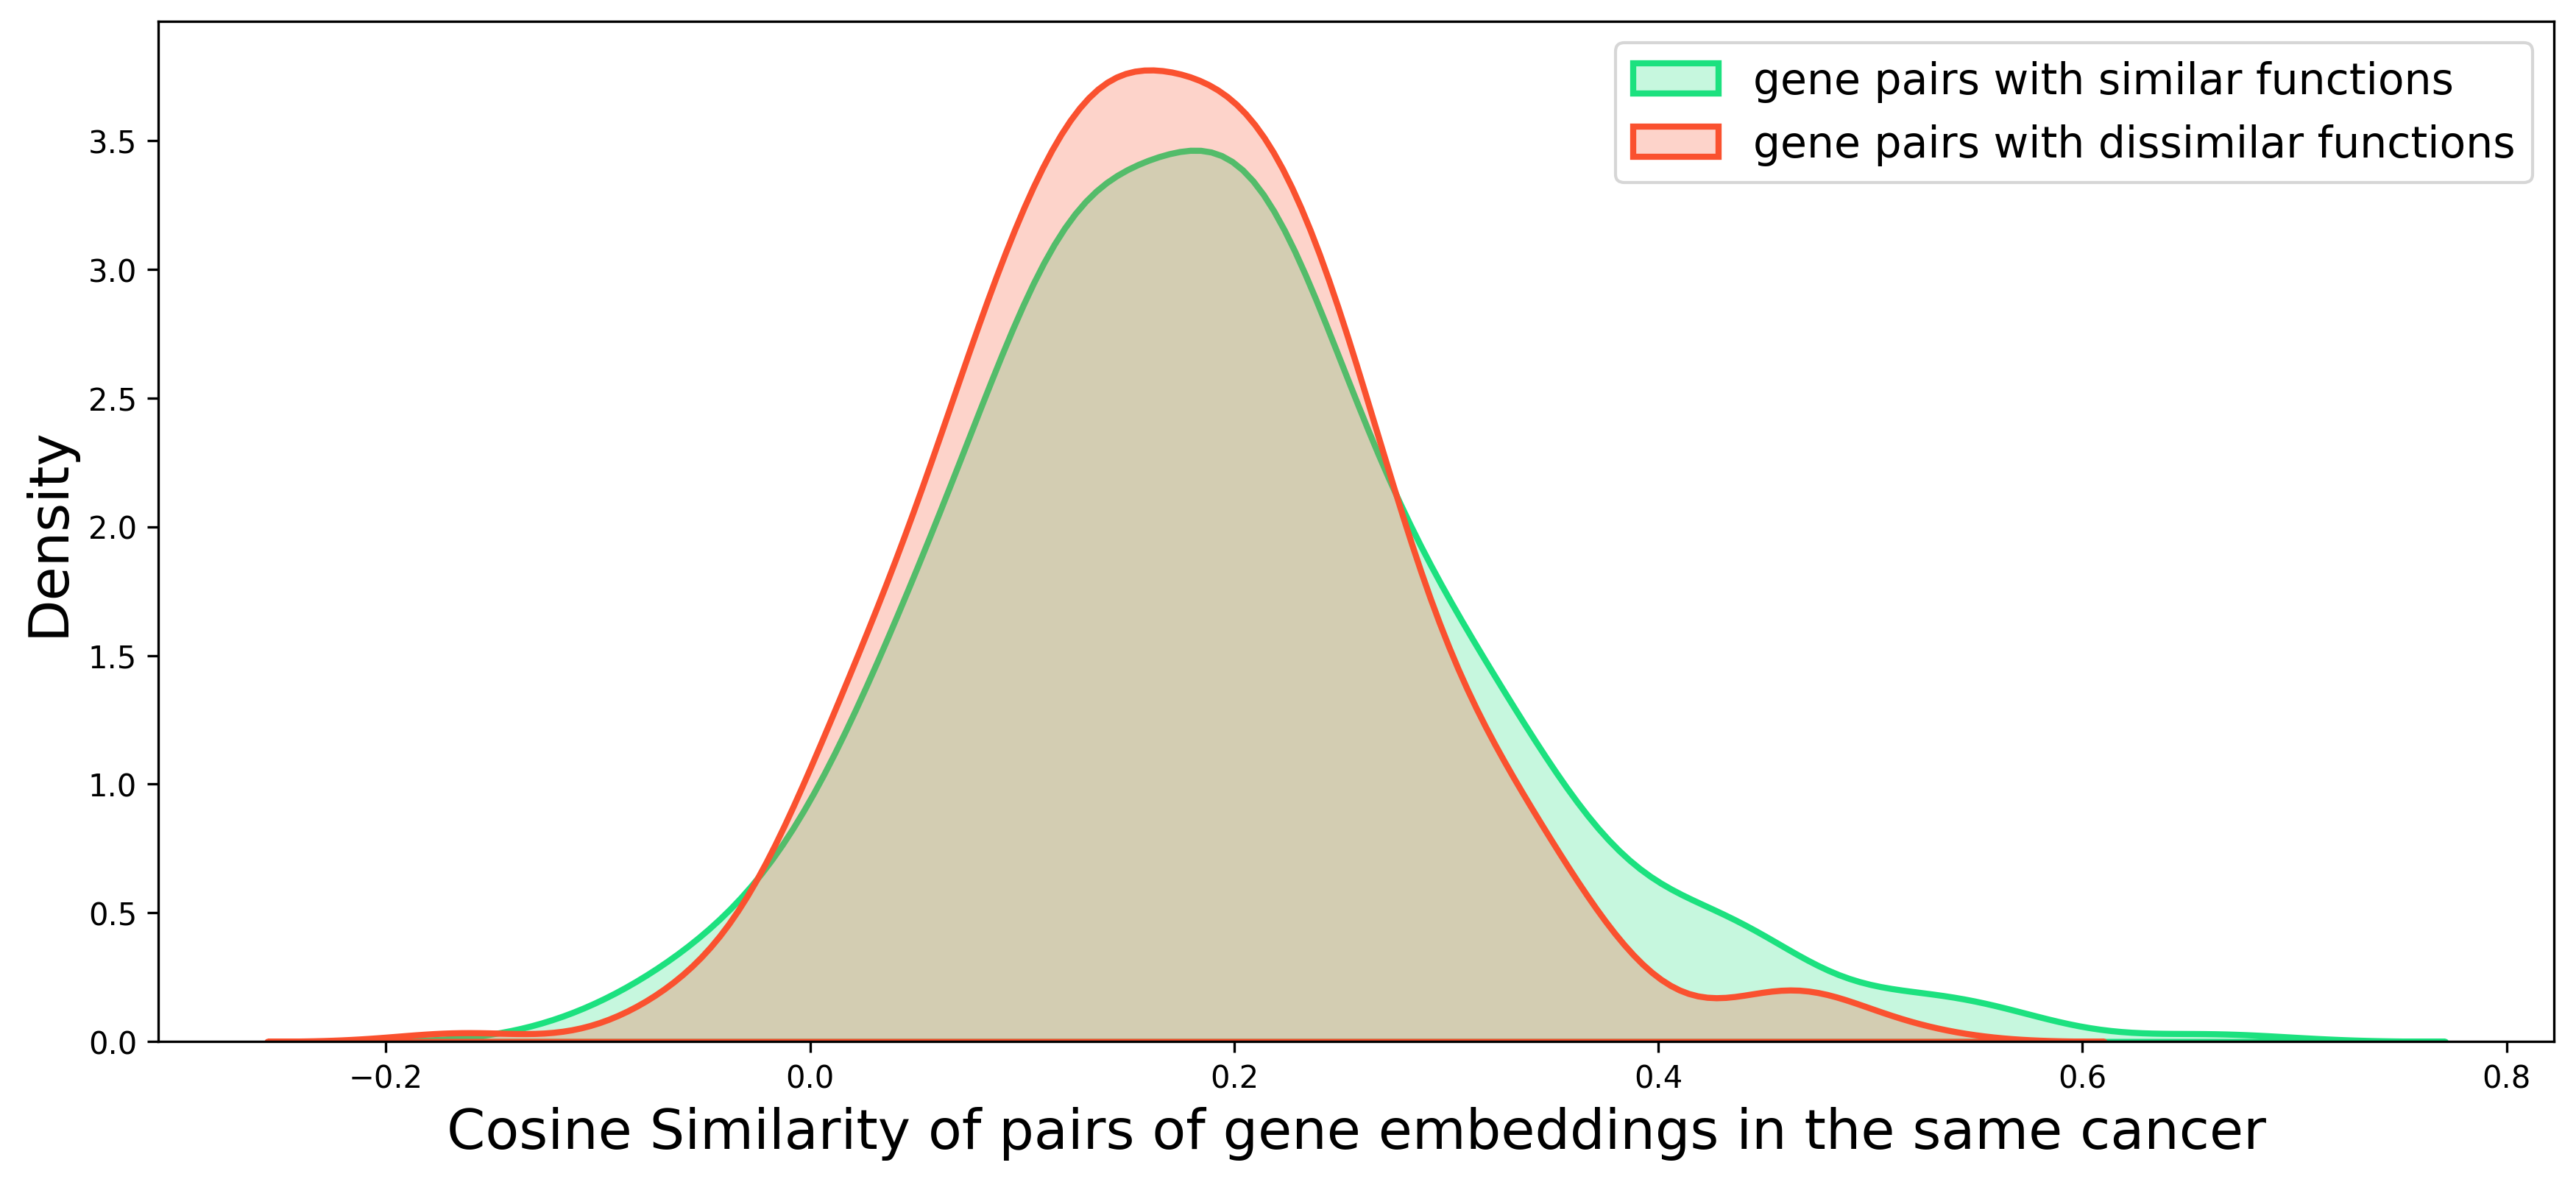

In [56]:
plot_func_sim_allcancer(cos_sim_all_geneformer, title="Pretrained Geneformer", go_thr=5)